# Разведочный анализ данных: MNIST (изображения)

Базовый EDA для датасета MNIST (файл `t10k-images.idx3-ubyte`): просмотр примеров изображений и усреднённого изображения.


Форма массива изображений: (2000, 28, 28)


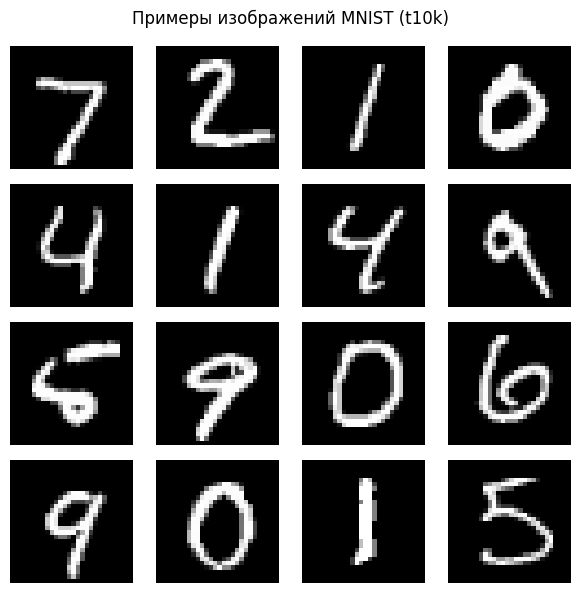

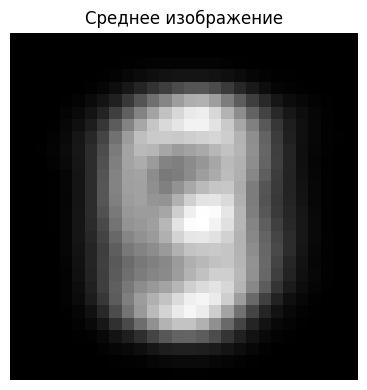

In [1]:
import os
import struct

import matplotlib.pyplot as plt
import numpy as np


DATA_DIR = os.path.join("..", "datasets", "mnist")
IMAGES_PATH = os.path.join(DATA_DIR, "t10k-images.idx3-ubyte")


def load_mnist_images(path, max_images=1000):
    with open(path, "rb") as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        assert magic == 2051
        num = min(num, max_images)
        buf = f.read(rows * cols * num)
        data = np.frombuffer(buf, dtype=np.uint8)
        data = data.reshape(num, rows, cols)
    return data


images = load_mnist_images(IMAGES_PATH, max_images=2000)
print("Форма массива изображений:", images.shape)

plt.figure(figsize=(6, 6))
for i in range(1, 17):
    plt.subplot(4, 4, i)
    plt.imshow(images[i - 1], cmap="gray")
    plt.axis("off")
plt.suptitle("Примеры изображений MNIST (t10k)")
plt.tight_layout()
plt.show()

mean_image = images.mean(axis=0)
plt.figure(figsize=(4, 4))
plt.imshow(mean_image, cmap="gray")
plt.title("Среднее изображение")
plt.axis("off")
plt.tight_layout()
plt.show()
